In [54]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
from numba import njit
import matplotlib.animation as animation
from matplotlib.widgets import Slider
import pandas as pd
from fss import DataCollapse
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
import matplotlib as mpl
import os

In [48]:
@njit
def apply_noise(psi, p):
    flip = np.random.rand(*psi.shape) < p
    return np.where(flip, -psi, psi)

@njit
def s_ij(psi_m, psi_p):
        return psi_m*psi_p

### Zero Temperature Glauber

In [49]:

@njit
def Glauber_sweep(psi,J): 
        #whole lattice update (but individual sites still selected probabilistically)
        L = psi.shape[0]
        DE = 0
        for _ in range(L*L): #random sequential update rule as opposed to a systematic sweep ensuring every site is covered. 
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            
            DE = 0
            
            #calculate syndromes with nns vertically
            DE += s_ij(psi[i,j], psi[(i+1) % L, j])
            DE += s_ij(psi[i,j], psi[(i-1) % L, j])
            DE += s_ij(psi[i,j], psi[i, (j+1) % L])
            DE += s_ij(psi[i,j], psi[i, (j-1) % L])
            
            DE *= 2*J

            if DE < 0:
                psi[i,j] *= -1
            elif DE ==  0:
                if np.random.rand() < 0.5:
                        psi[i,j] *= -1
        return psi


@njit
def Glauber_sweeps(psi, sweeps):
        for _ in range(sweeps):
                psi = Glauber_sweep(psi)
        return psi

### Testing for threshold

In [50]:
@njit
def FullEvolution(L, pnoise, T, J): #kind of similar to a previous function but useful because I initialize new state every time, also only T added not noise
    max_sweeps = 5*L*L #more generous 
    early_stop = 2*L*L

    psi_i = np.ones((L, L), dtype=np.int64)
    psi_i = apply_noise(psi_i,pnoise)
    psi_G = psi_i.copy()

    last_m = np.sum(psi_G)
    unchanged = 0 
    
    for t in range(max_sweeps): #doing in different loops so I can individually break them 
        psi_G = Glauber_sweep(psi_G, J)
        m = np.sum(psi_G)
        
        if np.abs(np.sum(psi_G)) == L*L:
            break
        if m == last_m:
            unchanged += 1
            if unchanged > early_stop:
                break
        else: 
            last_m = m
            unchanged = 0
    return psi_G

In [51]:
@njit
def FullEvolution_no_early_stop(L,pnoise, T, J): #kind of similar to a previous function but useful because I initialize new state every time, also only T added not noise
    max_sweeps = L*L*L

    psi_i = np.ones((L, L), dtype=np.int64)
    psi_i = apply_noise(psi_i,pnoise)
    psi_G = psi_i.copy()

    last_m = np.sum(psi_G)
    unchanged = 0 
    
    for t in range(max_sweeps): #doing in different loops so I can individually break them 
        psi_G = Glauber_sweep(psi_G, J)
        if np.abs(np.sum(psi_G)) == L*L:
            break
    return psi_G

## Noise Dependence

In [153]:
def Noise_analysis(L_arr, p_arr):
    J = 1
    Tn = 0.0
    trials = 2000
    flogical_arr = {L: [] for L in L_arr}
    fconv_arr = {L: [] for L in L_arr}
    SE_arr = {L: [] for L in L_arr}

    filename = '2DIsingDataCollapseV17.csv'
    file_exists = os.path.exists(filename)

    for L_i in L_arr:
        for p_i in p_arr:
            logical_fail = 0 
            convergence_fail = 0
            for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
                state_f = FullEvolution(L_i, p_i, Tn, J)
                if np.sum(state_f)/(L_i*L_i) != 1:
                    logical_fail  += 1
                if abs(np.sum(state_f))/(L_i*L_i) != 1:
                    convergence_fail +=1
            lfp = logical_fail/trials 
            cfp = convergence_fail/trials
            SE = np.sqrt(lfp*(1-lfp)/trials)
            SE_cf = np.sqrt(cfp*(1 - cfp)/trials)

            row = pd.DataFrame([{'p': p_i, 'L': L_i, 'lf': lfp, 'lf_SE': SE, 'cf': cfp, 'cf_SE': SE_cf}])
            row.to_csv(filename, mode='a', header=not file_exists, index=False)
            file_exists = True
            
            flogical_arr[L_i].append(lfp)
            SE_arr[L_i].append(SE)
            fconv_arr[L_i].append(cfp)

            print(f"L={L_i}, p={p_i:.6f} | pf={lfp:.6f} ± {SE:.6f} | cf={cfp:.6f}  ± {SE_cf:.6f}")
            
    return flogical_arr, SE_arr, fconv_arr

In [142]:
#Search Parameters and Arrays
L_arrdc = [20,40,60,80] 
p_arrdc = np.linspace(0.480,0.52, 15) 
flogical_arrdc, SE_arrdc, fconv_arrdc = Noise_analysis(L_arrdc, p_arrdc)

L=20, p=0.48: 100%|██████████| 1500/1500 [00:07<00:00, 210.25it/s]


L=20, p=0.480000 | pf=0.528667 ± 0.012889 | cf=0.310667  ± 0.011949


L=20, p=0.48: 100%|██████████| 1500/1500 [00:08<00:00, 187.27it/s]


L=20, p=0.482857 | pf=0.512667 ± 0.012906 | cf=0.289333  ± 0.011708


L=20, p=0.49: 100%|██████████| 1500/1500 [00:08<00:00, 176.10it/s]


...

L=40, p=0.514286 | pf=0.820667 ± 0.009905 | cf=0.287333  ± 0.011684


L=40, p=0.52: 100%|██████████| 1500/1500 [02:50<00:00,  8.79it/s]


L=40, p=0.517143 | pf=0.858000 ± 0.009012 | cf=0.284667  ± 0.011651


L=40, p=0.52: 100%|██████████| 1500/1500 [01:56<00:00, 12.93it/s]

L=40, p=0.520000 | pf=0.876667 ± 0.008490 | cf=0.262667  ± 0.011363


## DATA COLLAPSE

In [143]:
df = pd.read_csv('2DIsingDataCollapseV16.csv')
df_collapse = df[['p', 'L', 'lf', 'lf_SE']].copy()

# clip SE to avoid division by zero — floor at 1/trials
trials = 1500
df_collapse['lf_SE'] = df_collapse['lf_SE'].clip(lower=1/trials)

# adapt to package format
df_collapse = df_collapse.rename(columns={'lf': 'estimator', 'lf_SE': 'standard_error'})
df_collapse = df_collapse[df_collapse['L'] != 80]
df_collapse = df_collapse.set_index(['p', 'L'])
df_collapse

,,estimator,standard_error
p,L,,
0.480000,20,0.528667,0.012889
0.482857,20,0.512667,0.012906
0.485714,20,0.545333,0.012857
0.488571,20,0.578667,0.012749
0.491429,20,0.598667,0.012656
0.494286,20,0.622000,0.012520
0.497143,20,0.629333,0.012471
0.500000,20,0.667333,0.012166
0.502857,20,0.674667,0.012097


p_c=0.4989, nu=1.2857, chi2=0.5571
p_c error=(0.4972, 0.5004), nu error=(1.1214, 1.5765)


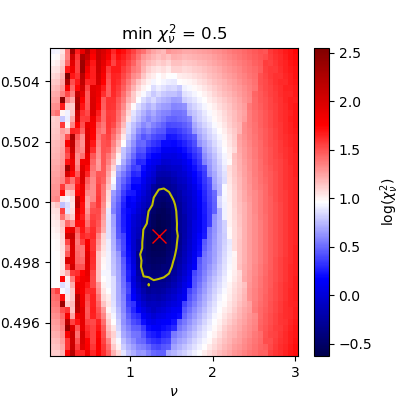

In [152]:
#Figuring out good initial values:
dc = DataCollapse(df_collapse, p_='p', L_='L', params={}, p_range=[0.480, 0.52],estimator='manual') #ideal window: [0.495, 0.505],
result = dc.parameter_sweep(
    p_c= np.linspace(0.495,0.505,50),
    nu=np.linspace(0, 3, 50),
    beta= 0, #np.linspace(-0.25,0.25,40),
    n_jobs=-1,  # use all cores
    backend='threading',  # multiprocessing
)
plt.savefig("ParameterOptimization2DI.png")

In [146]:
res = dc.datacollapse(p_c=0.4990 ,nu =1.2414, beta=0,p_c_vary=True, nu_vary=True, beta_vary=False)
print(res.params)

Parameters([('p_c', <Parameter 'p_c', value=0.4987539922396152 +/- 0.000503, bounds=[0:1]>), ('nu', <Parameter 'nu', value=1.3214415319410329 +/- 0.0727, bounds=[0.5:2]>), ('beta', <Parameter 'beta', value=0.0 (fixed), bounds=[0:1]>)])


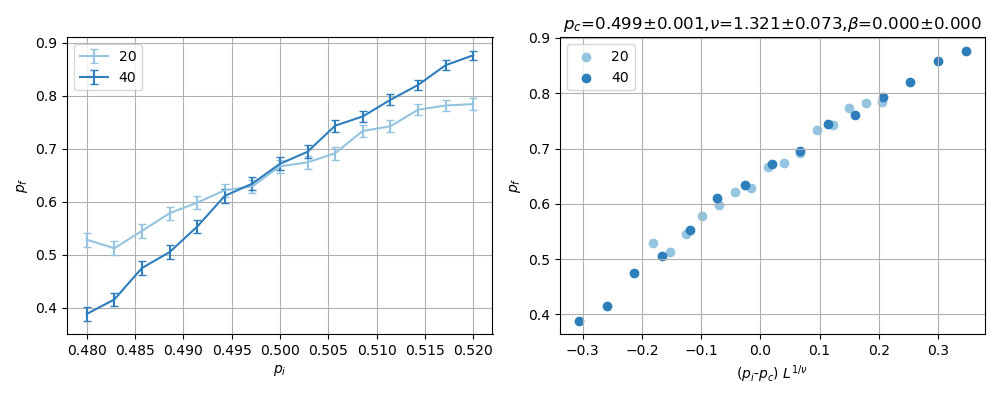

In [147]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

dc.plot_data_collapse(
    ax=ax1,
    raw=True,
    errorbar=True
)

dc.plot_data_collapse(
    ax=ax2
)

ax1.set_xlabel(r'$p_i$')
ax1.set_ylabel(r'$p_f$')
ax2.set_ylabel(r'$p_f$')

plt.tight_layout()
plt.savefig("DataCollapse(2DIsing).png")
plt.show()